## LTV Prediction 

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"C:\Users\RATHICK A\OneDrive\Desktop\data analytics\data\telco_customer_churn_processed.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


In [3]:
print("Columns in the dataset:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Columns in the dataset:
['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']

Data types:
CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet

In [5]:
# Historical revenue for each customer
df["Historical_Revenue"] = df["Total Charges"]

# Check the target
print(df[["CustomerID", "Tenure Months", "Monthly Charges",
          "Total Charges", "Historical_Revenue"]].head())

print("\nHistorical Revenue statistics:")
print(df["Historical_Revenue"].describe())

   CustomerID  Tenure Months  Monthly Charges  Total Charges  \
0  3668-QPYBK              2            53.85         108.15   
1  9237-HQITU              2            70.70         151.65   
2  9305-CDSKC              8            99.65         820.50   
3  7892-POOKP             28           104.80        3046.05   
4  0280-XJGEX             49           103.70        5036.30   

   Historical_Revenue  
0              108.15  
1              151.65  
2              820.50  
3             3046.05  
4             5036.30  

Historical Revenue statistics:
count    7043.000000
mean     2279.734304
std      2266.794470
min         0.000000
25%       398.550000
50%      1394.550000
75%      3786.600000
max      8684.800000
Name: Historical_Revenue, dtype: float64


In [6]:
# Select features for LTV prediction

features = [
    "Tenure Months",
    "Monthly Charges",
    "CLTV",
    "Contract",
    "Internet Service",
    "Payment Method",
    "Senior Citizen",
    "Partner",
    "Dependents"
]

X = df[features]
y = df["Historical_Revenue"]

print("Features used for LTV prediction:")
print(X.columns.tolist())

print("\nTarget:", y.name)
print("X shape:", X.shape)
print("y shape:", y.shape)

Features used for LTV prediction:
['Tenure Months', 'Monthly Charges', 'CLTV', 'Contract', 'Internet Service', 'Payment Method', 'Senior Citizen', 'Partner', 'Dependents']

Target: Historical_Revenue
X shape: (7043, 9)
y shape: (7043,)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training set: (5634, 9)
Testing set: (1409, 9)
Training target: (5634,)
Testing target: (1409,)


In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Numerical and categorical features
numeric_features = [
    "Tenure Months",
    "Monthly Charges",
    "CLTV"
]

categorical_features = [
    "Contract",
    "Internet Service",
    "Payment Method",
    "Senior Citizen",
    "Partner",
    "Dependents"
]

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Fit only on training data and transform both sets
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (5634, 19)
Processed testing shape: (1409, 19)


In [9]:
from sklearn.linear_model import LinearRegression

# Create and train the baseline LTV regression model
linear_model = LinearRegression()

linear_model.fit(X_train_processed, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions on test data
y_pred = linear_model.predict(X_test_processed)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear Regression Performance:")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

Linear Regression Performance:
MAE  : 560.75
RMSE : 709.26
R²   : 0.9032


In [12]:
# Make predictions using Random Forest
y_pred_rf = rf_model.predict(X_test_processed)

# Calculate evaluation metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regression Performance:")
print(f"MAE  : {mae_rf:.2f}")
print(f"RMSE : {rmse_rf:.2f}")
print(f"R²   : {r2_rf:.4f}")

Random Forest Regression Performance:
MAE  : 54.65
RMSE : 81.03
R²   : 0.9987


In [13]:
# Compare the regression models

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, mae_rf],
    "RMSE": [rmse, rmse_rf],
    "R²": [r2, r2_rf]
})

results

,Model,MAE,RMSE,R²
0,Linear Regression,560.752769,709.255180,0.903166
1,Random Forest,54.647086,81.031958,0.998736


In [14]:
# Compare actual and predicted historical revenue

comparison = pd.DataFrame({
    "Actual_Revenue": y_test.values,
    "Predicted_Revenue": y_pred_rf
})

comparison["Error"] = (
    comparison["Actual_Revenue"] - comparison["Predicted_Revenue"]
)

print(comparison.head(10))

   Actual_Revenue  Predicted_Revenue     Error
0         1269.55         1312.36975 -42.81975
1         1074.65         1013.26000  61.39000
2           40.90           39.12750   1.77250
3          519.15          496.11575  23.03425
4         4131.95         4106.61500  25.33500
5          829.55          804.16675  25.38325
6          171.45          185.04175 -13.59175
7         1574.45         1538.15125  36.29875
8           25.10           25.08225   0.01775
9          504.20          509.74500  -5.54500


In [15]:
# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Get feature importance from Random Forest
importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

# Sort by importance
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 10 features influencing Historical Revenue:")
print(importance.head(10))

Top 10 features influencing Historical Revenue:
                                          Feature  Importance
0                              num__Tenure Months    0.671973
1                            num__Monthly Charges    0.327292
2                                       num__CLTV    0.000300
9   cat__Payment Method_Bank transfer (automatic)    0.000042
11           cat__Payment Method_Electronic check    0.000040
10    cat__Payment Method_Credit card (automatic)    0.000039
4                          cat__Contract_One year    0.000034
3                    cat__Contract_Month-to-month    0.000031
15                                cat__Partner_No    0.000031
16                               cat__Partner_Yes    0.000029


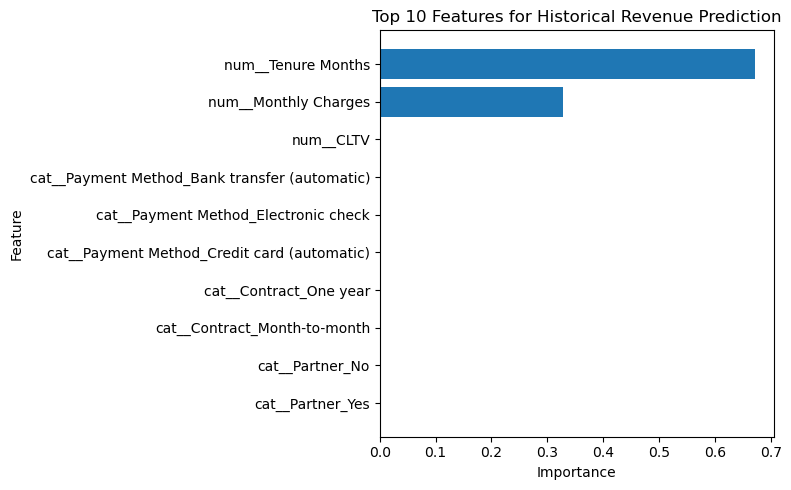

In [16]:
import matplotlib.pyplot as plt

# Select top 10 features
top_features = importance.head(10).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(8, 5))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features for Historical Revenue Prediction")

plt.tight_layout()
plt.show()

## Feature Importance Analysis

The feature importance of the Random Forest regression model was analyzed to understand which customer attributes contribute most to Historical Revenue prediction.

The results show that:

- **Tenure Months** is the most important feature, with an importance of approximately **0.672**.
- **Monthly Charges** is the second most important feature, with an importance of approximately **0.327**.
- **CLTV** and the categorical variables have very low importance compared with these two features.

This indicates that the customer's **length of service and monthly charges are the main factors used by the model to predict historical revenue**.

The high importance of Tenure Months and Monthly Charges is expected because historical revenue is closely related to the amount of time a customer has stayed and the charges accumulated during that period.

The very high Random Forest R² score should therefore be interpreted carefully. Since the target variable `Historical_Revenue` is derived from `Total Charges`, and `Total Charges` is naturally related to tenure and monthly payments, the model is highly effective at estimating historical revenue but this result should not be interpreted as proof of equally accurate future LTV prediction.